<a href="https://colab.research.google.com/github/amanak28/AI-LAB/blob/main/Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 1: BFS and DFS Traversal of a Graph:

Problem Statement:

A small graph, shaped like a tree with six nodes (A, B, C, D, E, F) and node A as the root, is given below. Write a Python program that:

1. Stores the graph using an adjacency list (a Python dictionary).

2. Performs a BFS traversal starting from node A.

3. Performs a DFS traversal starting from node A.

4. Prints both traversal orders, and draws two separate tree diagrams — one showing the order in which BFS visits the nodes, and another showing the order in which DFS visits the nodes.


---



In [ ]:
!pip install networkx matplotlib

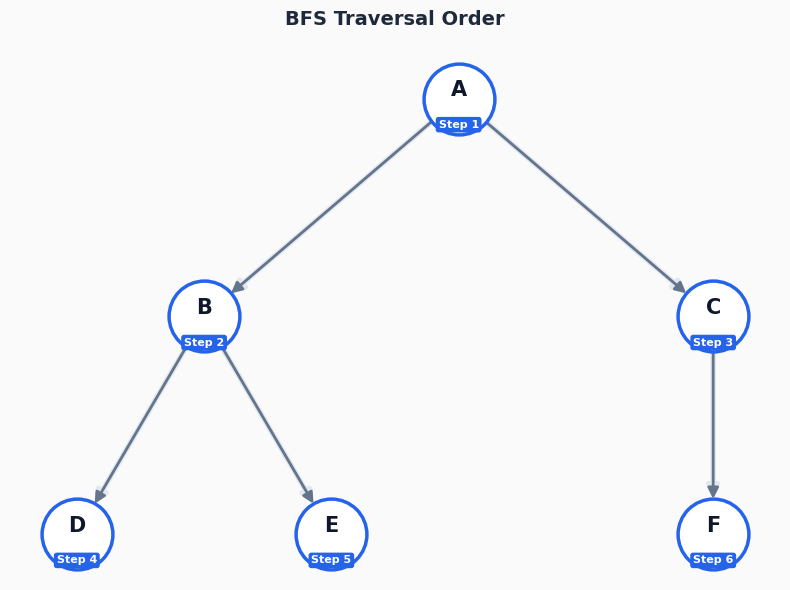

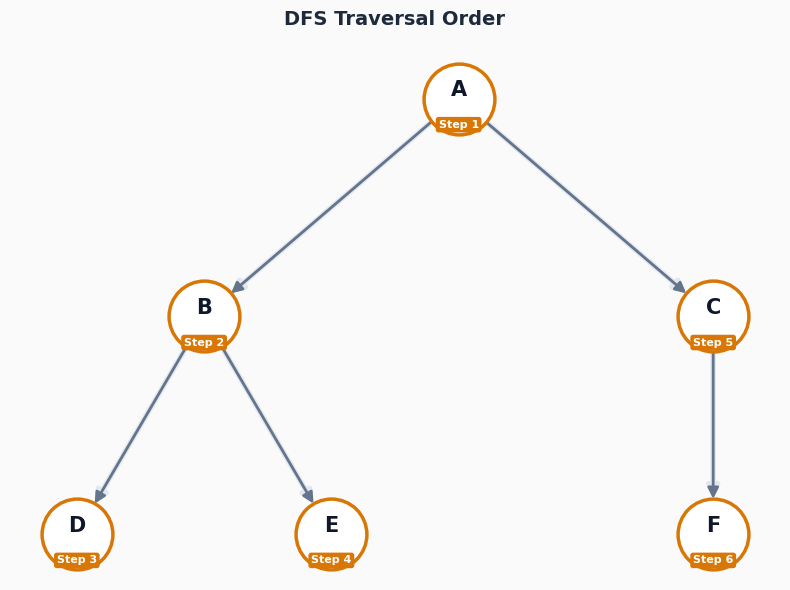

In [10]:
from collections import deque
import matplotlib.pyplot as plt
import networkx as nx

graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

def bfs(graph, start):
    visited = set()
    queue = deque([start])
    order = []
    visited.add(start)
    while queue:
        node = queue.popleft()
        order.append(node)
        for neighbour in graph[node]:
            if neighbour not in visited:
                visited.add(neighbour)
                queue.append(neighbour)
    return order

def dfs(graph, start):
    visited = set()
    order = []
    def dfs_recursive(node):
        visited.add(node)
        order.append(node)
        for neighbour in graph[node]:
            if neighbour not in visited:
                dfs_recursive(neighbour)
    dfs_recursive(start)
    return order

bfs_order = bfs(graph, 'A')
dfs_order = dfs(graph, 'A')

def draw_minimalist_tree(graph, order, title, theme_color='#4F46E5'):
    G = nx.DiGraph()
    for node in graph:
        for neighbour in graph[node]:
            G.add_edge(node, neighbour)

    pos = {
        'A': (0.0, 2.0),
        'B': (-1.0, 1.0),
        'C': (1.0, 1.0),
        'D': (-1.5, 0.0),
        'E': (-0.5, 0.0),
        'F': (1.0, 0.0)
    }

    fig, ax = plt.subplots(figsize=(8, 6), facecolor='#FAFAFA')
    ax.set_facecolor('#FAFAFA')

    # Soft background edge shadows
    nx.draw_networkx_edges(
        G, pos, ax=ax, edge_color='#E2E8F0', width=4.0,
        arrowsize=16, arrowstyle='-|>', node_size=2600
    )
    # Main subtle directional edges
    nx.draw_networkx_edges(
        G, pos, ax=ax, edge_color='#64748B', width=2.0,
        arrowsize=16, arrowstyle='-|>', node_size=2600
    )
    # Clean White Nodes with Theme Border
    nx.draw_networkx_nodes(
        G, pos, ax=ax, node_size=2600, node_color='#FFFFFF',
        edgecolors=theme_color, linewidths=2.5
    )

    for node, (x, y) in pos.items():
        step_num = order.index(node) + 1
        ax.text(x, y + 0.04, node, fontsize=15, fontweight='bold', color='#0F172A', ha='center', va='center')
        ax.text(
            x, y - 0.12, f"Step {step_num}", fontsize=8, fontweight='bold', color='#FFFFFF',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.25', facecolor=theme_color, edgecolor='none')
        )

    plt.title(title, fontsize=14, fontweight='bold', pad=20, color='#1E293B', family='sans-serif')
    plt.axis("off")
    plt.tight_layout()
    plt.show()

draw_minimalist_tree(graph, bfs_order, "BFS Traversal Order", theme_color='#2563EB')
draw_minimalist_tree(graph, dfs_order, "DFS Traversal Order", theme_color='#D97706')